In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

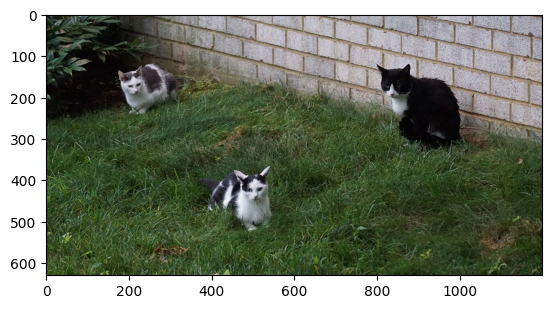

In [6]:
url = r"https://www.alleycat.org/wp-content/uploads/2016/09/FromTheField-PGCounty-1.jpg"

response = requests.get(url)
img_array = np.array(bytearray(response.content), dtype=np.uint8)

img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


plt.imshow(img)

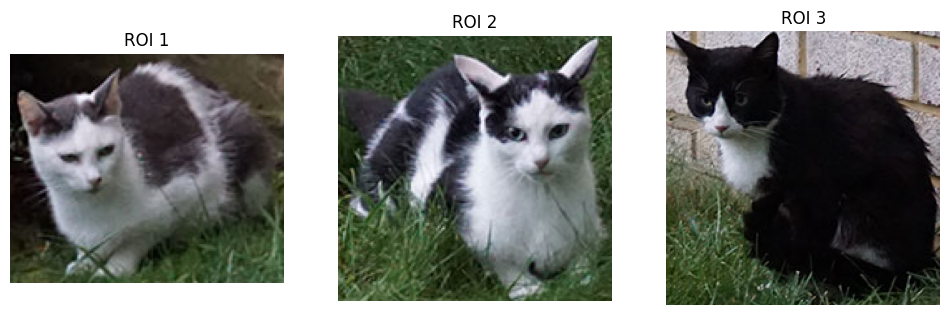

In [7]:
rois = [
    (170, 115, 155, 130),
    (385, 365, 165, 160),
    (795, 120, 210, 210)
]

ROIs = [img[y:y+h, x:x+w] for x, y, w, h in rois]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for idx, roi_img in enumerate(ROIs):
    axes[idx].imshow(roi_img)
    axes[idx].set_title(f"ROI {idx+1}")
    axes[idx].axis("off")  

imgROI1 = cv2.cvtColor(ROIs[0], cv2.COLOR_RGB2GRAY)
imgROI2 = cv2.cvtColor(ROIs[1], cv2.COLOR_RGB2GRAY)
imgROI3 = cv2.cvtColor(ROIs[2], cv2.COLOR_RGB2GRAY)
plt.show()

(np.float64(-0.5), np.float64(154.5), np.float64(129.5), np.float64(-0.5))

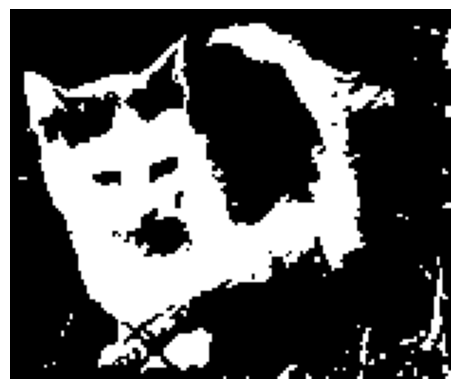

In [8]:
_, binary = cv2.threshold(imgROI1, 0, 255, cv2.THRESH_OTSU)
plt.imshow(binary, cmap="gray")
plt.axis("off")

(np.float64(-0.5), np.float64(164.5), np.float64(159.5), np.float64(-0.5))

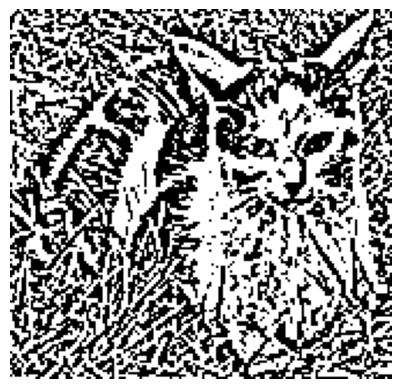

In [9]:
binary = cv2.adaptiveThreshold(imgROI2, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
plt.imshow(binary, cmap="gray")
plt.axis("off")


(np.float64(-0.5), np.float64(209.5), np.float64(209.5), np.float64(-0.5))

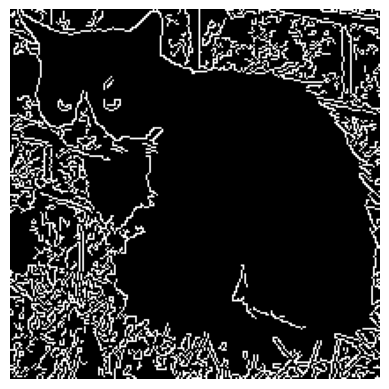

In [10]:
edges = cv2.Canny(imgROI3, 100, 200)
plt.imshow(edges, cmap="gray")  
plt.axis("off")

# EX2

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, filters
from skimage.segmentation import watershed

import os
import cv2


In [ ]:
# Định nghĩa lớp Dataset
class ImageDataset(Dataset):
    def __init__(self, image_dir, mask_dir, target_size=(512, 512), transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.target_size = target_size  # Kích thước mục tiêu cho hình ảnh và mask
        self.transform = transform
        self.image_files = sorted(os.listdir(image_dir))
        self.mask_files = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Đọc 
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  

        # Resize hình ảnh và mask về cùng kích thước
        image = cv2.resize(image, self.target_size)
        mask = cv2.resize(mask, self.target_size)
        
        # Chuyển đổi sang tensor nếu có transform
        if self.transform:
            image = self.transform(image)
            mask = transforms.ToTensor()(mask)  # Chỉ chuyển mask thành tensor, không chuẩn hóa

        return image, mask

# Định nghĩa transform cho hình ảnh
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Chuẩn hóa hình ảnh
])

# Create a dataset instance and data loader
trainDataset = ImageDataset(r'D:\Code_learning\CS-K49-IPCV_LAB\Resource\ikmalalfaozi\cat-detection-and-segmentation\versions\1\Cat\images\train', 
                       r'D:\Code_learning\CS-K49-IPCV_LAB\Resource\ikmalalfaozi\cat-detection-and-segmentation\versions\1\Cat\masks\train',
                       transform=transform)
valDataset = ImageDataset(r'D:\Code_learning\CS-K49-IPCV_LAB\Resource\ikmalalfaozi\cat-detection-and-segmentation\versions\1\Cat\images\val',
                          r'D:\Code_learning\CS-K49-IPCV_LAB\Resource\ikmalalfaozi\cat-detection-and-segmentation\versions\1\Cat\masks\val',
                          transform=transform)

trainLoader = DataLoader(trainDataset, batch_size=4, shuffle=True)
valLoader = DataLoader(valDataset, batch_size=4, shuffle=False)

# Kiểm tra số lượng mẫu và shape của batch
print(f"Số lượng mẫu trong train dataset: {len(trainDataset)}")
print(f"Số lượng mẫu trong val dataset: {len(valDataset)}")
for img, mask in trainLoader:
    print(f"Shape của hình ảnh trong batch: {img.shape}")
    print(f"Shape của mask trong batch: {mask.shape}")
    break

Số lượng mẫu trong train dataset: 1000
Số lượng mẫu trong val dataset: 100
Shape của hình ảnh trong batch: torch.Size([4, 3, 512, 512])
Shape của mask trong batch: torch.Size([4, 1, 512, 512])


In [13]:
class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        # if you have padding issues, see
        # https://github.com/HaiyongJiang/U-Net-Pytorch-Unstructured-Buggy/commit/0e854509c2cea854e247a9c615f175f76fbb2e3a
        # https://github.com/xiaopeng-liao/Pytorch-UNet/commit/8ebac70e633bac59fc22bb5195e513d5832fb3bd
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)
        

In [14]:
class UNet(nn.Module):
    def __init__(self, n_channels=3, out_channels=1, bilinear=True):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.bilinear = bilinear

        self.inc = (DoubleConv(n_channels, 64))
        self.down1 = (Down(64, 128))
        self.down2 = (Down(128, 256))
        self.down3 = (Down(256, 512))
        factor = 2 if bilinear else 1
        self.down4 = (Down(512, 1024 // factor))
        self.up1 = (Up(1024, 512 // factor, bilinear))
        self.up2 = (Up(512, 256 // factor, bilinear))
        self.up3 = (Up(256, 128 // factor, bilinear))
        self.up4 = (Up(128, 64, bilinear))
        self.outc = (OutConv(64, out_channels))
        

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

    def use_checkpointing(self):
        self.inc = torch.utils.checkpoint(self.inc)
        self.down1 = torch.utils.checkpoint(self.down1)
        self.down2 = torch.utils.checkpoint(self.down2)
        self.down3 = torch.utils.checkpoint(self.down3)
        self.down4 = torch.utils.checkpoint(self.down4)
        self.up1 = torch.utils.checkpoint(self.up1)
        self.up2 = torch.utils.checkpoint(self.up2)
        self.up3 = torch.utils.checkpoint(self.up3)
        self.up4 = torch.utils.checkpoint(self.up4)
        self.outc = torch.utils.checkpoint(self.outc)

In [15]:
import torch.optim as optim
device = "cuda"
model = UNet().to(device)

criterion = nn.BCEWithLogitsLoss()  # Loss cho segmentation nhị phân
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 10  # Số epoch train

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for images, masks in trainLoader:
        images, masks = images.to(device), masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, masks in valLoader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss/len(trainLoader):.4f}, Val Loss: {val_loss/len(trainLoader):.4f}")


Epoch [1/10], Train Loss: 0.3804, Val Loss: 0.0411
Epoch [2/10], Train Loss: 0.3608, Val Loss: 0.0406
Epoch [3/10], Train Loss: 0.3577, Val Loss: 0.0416
Epoch [4/10], Train Loss: 0.3565, Val Loss: 0.0406
